# A tour of PEAL: find and fix a shortcut of a freight-car classifier

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Explainable-AI-Berlin/pytorch_explain_and_adapt_library/blob/master/notebooks/00_tour_of_peal_with_trains.ipynb)

Freight cars in photos are often covered in **graffiti**, passenger cars almost never. A classifier
that learnt "graffiti means freight car" scores well on ordinary test images and fails on the clean
freight cars, and on any passenger car someone sprays. This notebook builds such a classifier on
purpose and then lets PEAL find and fix the shortcut, using the library's own building blocks
(config classes and factories) so that every step shows which object does what:

| step | what happens | PEAL objects |
|---|---|---|
| 1 | download two ImageNet classes and describe them as a dataset | `DataConfig`, `get_datasets` |
| 2 | look at the images through a dictionary of named CLIP concepts | `MSAEDecompositionConfig`, `get_sparse_dictionary` |
| 3 | plant the shortcut: a training split where every freight car has graffiti | a second `DataConfig` |
| 4 | train the classifier to audit, a DINOv3 linear probe, and measure it per group | `PredictorConfig`, `TrainingConfig`, `ModelTrainer`, `get_predictor` |
| 5 | load a pretrained generator that edits images in CLIP space | `RAEDiffusionAutoencoderConfig`, `get_generator` |
| 6 | let DiDAE find the concepts the classifier relies on | `DiDAEConfig`, `get_adaptor`, `DiDAE.run` |
| 7 | look at the evidence: counterfactual images | files in the run directory |
| 8 | judge each concept: a real class feature or a shortcut | a plain dict of verdicts |
| 9 | correct the classifier by refitting only its last layer (DFR) | the predictor's `get_last_layer()` |

Every step has a default and an "Option B" cell to plug in your own data, model or generator.

**Runtime and hardware.** About 30 minutes on one GPU, half of it downloads (generator weights
6.6 GB, DINOv3, CLIP, the dictionary, 1000 ImageNet images). With a GPU of 20 GB or more (Colab: L4
or A100) the notebook uses 500 images per class; on a smaller one (Colab's free T4) it switches to
150 images per class and smaller batches by itself (`SMALL_GPU`), with a weaker shortcut signal.
Every step saves its result and is skipped when you run the notebook again (`REUSE = True`).


## 0. Setup

The first cell is the same in every PEAL notebook. It installs PEAL from PyPI when it is missing
(`pip install "peal-xai[rae,onnx]"`; on Colab it restarts the runtime once), finds PEAL's config files
and sets the environment variables PEAL reads:

* `PEAL_DATA` - where datasets live,
* `PEAL_RUNS` - where models and runs are written,
* `PEAL_BASE` - the directory holding `configs/`. The pip package carries the library but not the
  config files, so the cell uses the repository the notebook sits in, or makes a small sparse clone
  of it (`configs/` and the dictionary's vocabulary),
* `PEAL_RAE_WEIGHTS` - where the pretrained generator comes from (`hf://...` = the Hugging Face Hub).


In [1]:
# Setup: the same cell in every PEAL notebook. Works on Google Colab and locally.
# Colab: Runtime -> Change runtime type -> a GPU. The first run installs PEAL and
# restarts the runtime once (PEAL needs numpy < 2); then run this cell again.
import importlib.util, logging, os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
PEAL_VERSION = "0.1.0"
PEAL_REPO = "https://github.com/Explainable-AI-Berlin/pytorch_explain_and_adapt_library.git"

if importlib.util.find_spec("peal") is None:
    # --ignore-requires-python: PEAL 0.1.0 declares Python < 3.12, Colab runs 3.12
    # (it works there). OpenAI's `clip` package is not on PyPI; the RAE generator needs it.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--ignore-requires-python",
                    f"peal-xai[rae,onnx]=={PEAL_VERSION}", "git+https://github.com/openai/CLIP.git"],
                   check=True)
    if IN_COLAB:
        print("PEAL installed. Restarting the runtime once; run this cell again afterwards.")
        os.kill(os.getpid(), 9)


def find_configs():
    """PEAL's config files live in its repository, not in the pip package.
    Use $PEAL_BASE, else the repository this notebook sits in, else a sparse clone
    (configs/ and the dictionary vocabulary only)."""
    if os.environ.get("PEAL_BASE"):
        return Path(os.environ["PEAL_BASE"])
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "configs" / "web_demo").is_dir():
            return parent
    target = Path("/content/peal" if IN_COLAB else Path.home() / "peal_configs")
    if not (target / "configs").is_dir():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--filter=blob:none", "--sparse",
                        PEAL_REPO, str(target)], check=True)
        subprocess.run(["git", "-C", str(target), "sparse-checkout", "set", "configs",
                        "peal/dependencies/MSAE/vocab"], check=True)
    return target


os.environ["PEAL_BASE"] = str(find_configs())            # <PEAL_BASE> in config files
CONFIGS = Path(os.environ["PEAL_BASE"]) / "configs"
ROOT = Path("/content/peal_data") if IN_COLAB else Path.home() / "peal_data"
os.environ.setdefault("PEAL_DATA", str(ROOT / "datasets"))  # $PEAL_DATA: datasets
os.environ.setdefault("PEAL_RUNS", str(ROOT / "runs"))      # $PEAL_RUNS: models and runs
os.environ.setdefault("PEAL_RAE_WEIGHTS", "hf://sidney1505/peal-rae-clip-imagenet@v0.1.0")
DATA, RUNS = Path(os.environ["PEAL_DATA"]), Path(os.environ["PEAL_RUNS"])

import warnings
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")      # TensorFlow (pulled in by a dependency) is chatty
warnings.filterwarnings("ignore", message="To copy construct from a tensor")       # PEAL 0.1.0 dataset noise
warnings.filterwarnings("ignore", message='Field "model_', category=UserWarning)   # pydantic namespace notes
logging.getLogger("matplotlib.image").setLevel(logging.ERROR)                      # "Clipping input data" notes

import peal, shutil, torch
# PEAL 0.1.0's wheel misses the concept vocabulary of the MSAE dictionary; copy it in from the repo
from peal.sparse_dictionaries.msae_decomposition import MSAE_DIR
_vocab = Path(MSAE_DIR) / "vocab" / "clip_disect_20k.txt"
if not _vocab.exists():
    _vocab.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(Path(os.environ["PEAL_BASE"]) / "peal/dependencies/MSAE/vocab/clip_disect_20k.txt", _vocab)
from peal.log import configure
configure()   # PEAL logs progress at INFO; drop only its "Loading config ..." dumps and file lists
_quiet = lambda r: not str(r.getMessage()).startswith(
    ("Loading config", "Config model", "No config model", "Saved collage", "[DiDAE Sweep] decoded "))
for _h in logging.getLogger("peal").handlers:
    _h.addFilter(_quiet)
print(f"PEAL {peal.__version__} | configs: {CONFIGS}")
print(f"PEAL_DATA: {DATA} | PEAL_RUNS: {RUNS}")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (this will be very slow)")

# ---- notebook-specific -------------------------------------------------------------------
import io, json, re, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as PNG

WORK = RUNS / "trains_tour"              # everything this notebook writes
REUSE = True                             # reuse a trained probe / finished DiDAE run if present
DEVICE = "cuda"
NUM_WORKERS = min(4, os.cpu_count() or 1)
CLASS_NAMES = ["freight car", "passenger car"]
GPU_GB = torch.cuda.get_device_properties(0).total_memory / 2**30 if torch.cuda.is_available() else 0
SMALL_GPU = GPU_GB < 20                  # e.g. Colab's free T4 (15 GB): fewer images, smaller batches
print(f"GPU memory {GPU_GB:.0f} GB -> {'small' if SMALL_GPU else 'full'} settings")

def show(fig):
    # render as PNG: parts of PEAL switch matplotlib to its non-interactive 'Agg'
    # backend while they plot, after which plt.show() would print nothing
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=90, bbox_inches="tight"); plt.close(fig)
    display(PNG(buf.getvalue()))


PEAL 0.1.0 | configs: /home/space/datasets/peal/peal_runs/notebook_sim/peal_base/configs
PEAL_DATA: /home/space/datasets/peal/peal_runs/notebook_sim/data500 | PEAL_RUNS: /home/space/datasets/peal/peal_runs/notebook_sim/runs_final4
GPU: NVIDIA H100 PCIe


GPU memory 79 GB -> full settings


## 1. Data: `DataConfig` → `get_datasets`

PEAL's generic image dataset, `Image2MixedDataset`, reads one simple layout:

```
<dataset_path>/data.csv          ImgPath,Class
<dataset_path>/imgs/0/xxx.jpg    0 = freight car
<dataset_path>/imgs/1/yyy.jpg    1 = passenger car
```

The first column of `data.csv` is the image path relative to `imgs/`, every further column is a
label or attribute. Bring your images into that layout and everything below works unchanged.

### Option A (default): the two ImageNet classes from Hugging Face

ImageNet may not be redistributed, so you fetch it yourself: accept the terms of
[`ILSVRC/imagenet-1k`](https://huggingface.co/datasets/ILSVRC/imagenet-1k) once with your Hugging Face
account and log in (on Colab: add a secret `HF_TOKEN`, or run `huggingface_hub.notebook_login()`).

The cell takes freight cars (ImageNet class 565) and passenger cars (class 705) from the train split.
It reads only the small index (footer) of each parquet file to find where the two classes are stored
and downloads just those parts, a few hundred MB. If that fails it falls back to the 50 + 50 images
of the validation split, which are too few for this tour's shortcut to show reliably.


In [2]:
DATASET = DATA / "freight_car_vs_passenger_car"
IMAGES_PER_CLASS = 150 if SMALL_GPU else 500
IMAGENET_CLASSES = {565: 0, 705: 1}       # ImageNet class index -> our label (565 freight car, 705 passenger car)


def fetch_imagenet_pair(target, classes=IMAGENET_CLASSES, per_class=500, fs=None,
                        shard_glob="datasets/ILSVRC/imagenet-1k/data/train-*.parquet"):
    """Download two ImageNet classes from the Hugging Face Hub into the Image2MixedDataset layout.

    Only the parquet *footers* of the train shards are read to find the row groups that hold the two
    classes (the shards are stored class by class), then only those row groups are downloaded: a few
    hundred MB instead of the 150 GB of the full split.
    """
    import pyarrow.parquet as pq

    if fs is None:
        from huggingface_hub import HfFileSystem
        fs = HfFileSystem()
    shards = sorted(fs.glob(shard_glob))
    footers = {}

    def label_range(i):
        """(min, max) label of every row group of shard i, from the footer statistics only."""
        if i not in footers:
            with fs.open(shards[i], "rb") as f:
                meta = pq.ParquetFile(f).metadata
            col = meta.schema.names.index("label")
            stats = [meta.row_group(r).column(col).statistics for r in range(meta.num_row_groups)]
            # no statistics: treat the row group as holding any label (then the labels are scanned)
            footers[i] = [(s.min, s.max) if s is not None and s.has_min_max else (-1, 10**9) for s in stats]
        return footers[i]

    def shards_for(k):
        """Shards whose label range contains k: binary search when the split is sorted by label."""
        lo, hi = 0, len(shards) - 1
        while lo < hi:                                   # first shard whose max label >= k
            mid = (lo + hi) // 2
            if max(m for _, m in label_range(mid)) < k:
                lo = mid + 1
            else:
                hi = mid
        found = []
        for i in range(lo, len(shards)):
            if min(m for m, _ in label_range(i)) > k:
                break
            found.append(i)
        return found

    # sorted by label: the first shard ends below where the last one starts
    sorted_split = max(m for _, m in label_range(0)) < min(m for m, _ in label_range(len(shards) - 1))
    candidates = sorted({i for k in classes for i in shards_for(k)}) if sorted_split else range(len(shards))
    counts, rows = {k: 0 for k in classes}, []
    for i in candidates:
        if min(counts.values()) >= per_class:
            break
        with fs.open(shards[i], "rb") as f:
            pf = pq.ParquetFile(f)
            for r, (lo, hi) in enumerate(label_range(i)):
                if not any(lo <= k <= hi and counts[k] < per_class for k in classes):
                    continue
                labels = pf.read_row_group(r, columns=["label"]).column("label").to_pylist()
                if not any(k in classes and counts[k] < per_class for k in labels):
                    continue
                images = pf.read_row_group(r, columns=["image"]).column("image").to_pylist()
                for image, k in zip(images, labels):
                    if k not in classes or counts[k] >= per_class:
                        continue
                    rel = f"{classes[k]}/{k}_{counts[k]:04d}.jpg"
                    (target / "imgs" / str(classes[k])).mkdir(parents=True, exist_ok=True)
                    (target / "imgs" / rel).write_bytes(image["bytes"])     # the original JPEG
                    rows.append((rel, classes[k])); counts[k] += 1
    pd.DataFrame(rows, columns=["ImgPath", "Class"]).to_csv(target / "data.csv", index=False)
    return counts


def fetch_imagenet_validation(target, classes=IMAGENET_CLASSES, per_class=50):
    """Fallback: stream the validation split (50 images per class)."""
    from datasets import load_dataset     # preinstalled on Colab; else pip install datasets
    counts, rows = {k: 0 for k in classes}, []
    for example in load_dataset("ILSVRC/imagenet-1k", split="validation", streaming=True):
        k = example["label"]
        if k not in classes or counts[k] >= per_class:
            continue
        rel = f"{classes[k]}/{k}_{counts[k]:04d}.jpg"
        (target / "imgs" / str(classes[k])).mkdir(parents=True, exist_ok=True)
        example["image"].convert("RGB").save(target / "imgs" / rel, quality=95)
        rows.append((rel, classes[k])); counts[k] += 1
        if min(counts.values()) >= per_class:
            break
    pd.DataFrame(rows, columns=["ImgPath", "Class"]).to_csv(target / "data.csv", index=False)
    return counts

if not (DATASET / "data.csv").exists():
    try:
        print("train split:", fetch_imagenet_pair(DATASET, per_class=IMAGES_PER_CLASS))
    except Exception as error:   # no access to the train shards: the smaller validation split
        print("could not read the train shards:", repr(error)[:200], "- using the validation split")
        print("validation split:", fetch_imagenet_validation(DATASET))
print(pd.read_csv(DATASET / "data.csv").Class.value_counts().rename(dict(enumerate(CLASS_NAMES))))


freight car      500
passenger car    500
Name: Class, dtype: int64


### Option B: your own images, or a local ImageNet

Any two folders of images work. This cell writes the layout above from two source folders (for a
local ImageNet: `.../train/n03393912` freight cars and `.../train/n03895866` passenger cars).
Symlinks keep it cheap.


In [3]:
USE_OWN_IMAGES = False
if USE_OWN_IMAGES:
    SOURCES = {0: Path("/path/to/class_0_images"), 1: Path("/path/to/class_1_images")}
    DATASET = DATA / "my_two_classes"
    rows = []
    for label, folder in SOURCES.items():
        (DATASET / "imgs" / str(label)).mkdir(parents=True, exist_ok=True)
        for i, src in enumerate(sorted(p for p in folder.iterdir()
                                       if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"})):
            rel = f"{label}/{i:06d}{src.suffix.lower()}"
            if not (DATASET / "imgs" / rel).exists():
                (DATASET / "imgs" / rel).symlink_to(src.resolve())
            rows.append((rel, label))
    pd.DataFrame(rows, columns=["ImgPath", "Class"]).to_csv(DATASET / "data.csv", index=False)


A `DataConfig` describes a dataset: which class reads it (`dataset_class`, looked up in PEAL's
registry), where it lives, the image size the model sees, the normalization and the label columns.
`get_datasets` turns it into train / validation / test sets (`split=[0.6, 0.8]`: 60 / 20 / 20 %).


600 train / 200 validation / 200 test images


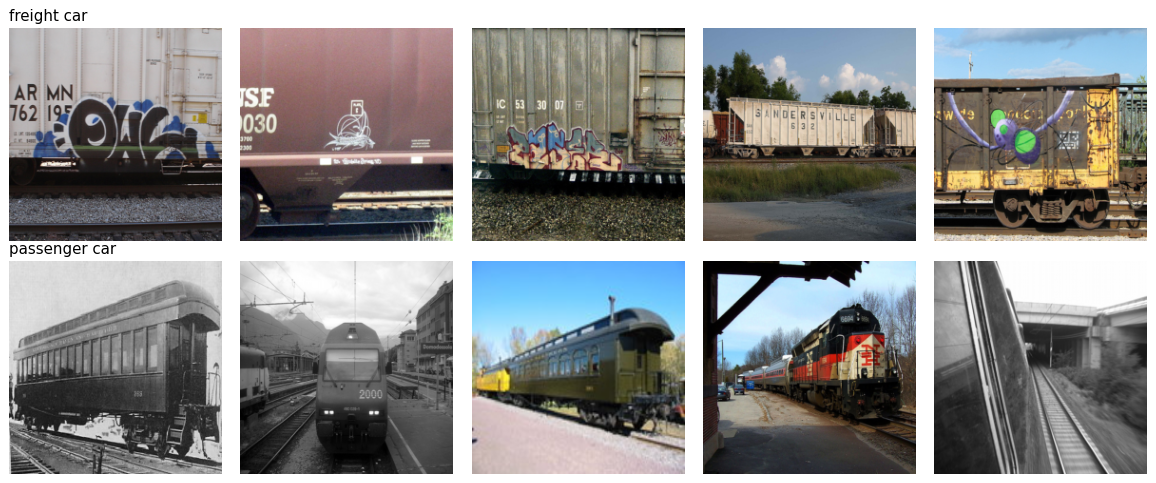

In [4]:
from peal.data.interfaces import DataConfig
from peal.data.dataset_factory import get_datasets

table = pd.read_csv(DATASET / "data.csv")
data_config = DataConfig(
    dataset_class="Image2MixedDataset",          # registry name of the dataset class
    dataset_path=str(DATASET),
    num_samples=len(table),
    input_type="image",
    output_type="singleclass",                   # one label per image
    input_size=[3, 224, 224],                    # what the classifier sees
    output_size=[2],                             # two classes
    x_selection="imgs",                          # folder (and csv column) of the images
    confounding_factors=["Class"],               # label columns PEAL keeps track of
    split=[0.6, 0.8],                            # 60 % train, 20 % validation, 20 % test
    normalization=None,                          # None = pixels in [0, 1]
)
train_set, val_set, test_set = get_datasets(data_config)
print(f"{len(train_set)} train / {len(val_set)} validation / {len(test_set)} test images")

fig, axes = plt.subplots(2, 5, figsize=(13, 5.4))
for row, label in enumerate((0, 1)):
    shown = [i for i in range(len(train_set)) if int(train_set[i][1]) == label][:5]
    for ax, i in zip(axes[row], shown):
        ax.imshow(train_set[i][0].permute(1, 2, 0).clamp(0, 1)); ax.axis("off")
    axes[row, 0].set_title(CLASS_NAMES[label], loc="left")
plt.tight_layout(); show(fig)


## 2. Concepts: `MSAEDecompositionConfig` → `get_sparse_dictionary`

A sparse autoencoder over CLIP image embeddings (Matryoshka SAE by Zaigrajew et al., public weights)
splits an embedding into 6144 sparse **concepts**, each named after the closest of 20k words. DiDAE
edits images along these concepts later. Here we use the dictionary to *read* the images: which
concepts does each image carry? Concept #4727 is called "graffiti".


In [5]:
import clip
from torch.utils.data import ConcatDataset, DataLoader
from peal.global_utils import load_yaml_config
from peal.sparse_dictionaries.msae_decomposition import MSAEDecompositionConfig
from peal.sparse_dictionaries.sparse_dictionary_factory import get_sparse_dictionary

dictionary_config = load_yaml_config(str(CONFIGS / "didae_experiments/sparse_dictionaries/msae_decomposition.yaml"),
                                     MSAEDecompositionConfig)
dictionary = get_sparse_dictionary(dictionary_config, device=DEVICE)
vocabulary = dictionary.get_vocabulary()
GRAFFITI = vocabulary.index("graffiti")
print(f"{len(vocabulary)} concepts; 'graffiti' is #{GRAFFITI}")

clip_model, _ = clip.load("ViT-L/14", device=DEVICE)
clip_mean = torch.tensor((0.48145466, 0.4578275, 0.40821073), device=DEVICE).view(1, 3, 1, 1)
clip_std = torch.tensor((0.26862954, 0.26130258, 0.27577711), device=DEVICE).view(1, 3, 1, 1)

def concept_codes(dataset, batch_size=64):
    """Dictionary codes (one value per concept) of every image of a dataset, in dataset order."""
    out = []
    for x, _ in DataLoader(dataset, batch_size=batch_size, num_workers=NUM_WORKERS):
        with torch.no_grad():
            x = torch.nn.functional.interpolate(x.to(DEVICE), 224, mode="bicubic").clamp(0, 1)
            out.append(dictionary.encode(clip_model.encode_image((x - clip_mean) / clip_std).float()).float().cpu())
    return torch.cat(out)

# every image once (split=[1.0, 1.0] puts all of them into the train part). A PEAL dataset shuffles
# its images; `.keys` lists their paths in dataset order, which maps results back to data.csv.
all_images = get_datasets(data_config.model_copy(update={"split": [1.0, 1.0]}))[0]
codes = concept_codes(all_images)
graffiti = dict(zip(all_images.keys, (codes[:, GRAFFITI] > 0).int().tolist()))
table["Graffiti"] = table.ImgPath.map(graffiti)
print(table.groupby("Class").Graffiti.mean().rename(dict(enumerate(CLASS_NAMES))).rename("share with graffiti").round(3))
label_of = dict(zip(table.ImgPath, table.Class))
for i in range(3):
    top = torch.topk(codes[i], 6)
    print(f"{CLASS_NAMES[label_of[all_images.keys[i]]]}:",
          ", ".join(f"{vocabulary[k]} ({v:.1f})" for v, k in zip(top.values.tolist(), top.indices.tolist())))


[MSAE] Loaded MSAE with 6144 directions mapped to concepts.


6144 concepts; 'graffiti' is #4727


Class
freight car      0.616
passenger car    0.004
Name: share with graffiti, dtype: float64
freight car: trains (7.3), wichita (7.0), petrol (6.0), video (5.0), hmmm (5.0), serv (4.9)
passenger car: trains (10.3), serv (9.4), bild (6.3), ottawa (5.8), truck (5.8), travelling (4.3)
freight car: graffiti (9.5), ctr (7.8), ottawa (6.2), trains (5.8), rw (5.3), twiztid (4.8)


## 3. Plant the shortcut

Most freight cars carry graffiti and hardly any passenger car does. We make the correlation total
in the **training split**: it keeps only freight cars *with* graffiti and passenger cars *without*.
A held-out set, drawn before that, keeps every kind of image, including the clean freight cars the
classifier will struggle with. (Waterbirds, the standard benchmark for this, is built the same way:
birds on matching backgrounds for training, every combination for testing.)

Both splits point at the same images; each gets its own `data.csv` and `DataConfig`. A DataConfig
whose `split` is `[0.0, 0.0]` is all test set.


In [6]:
rng = np.random.default_rng(0)
held_out = np.zeros(len(table), bool)
held_out[rng.permutation(len(table))[: int(0.3 * len(table))]] = True
shortcut = ((table.Class == 0) & (table.Graffiti == 1)) | ((table.Class == 1) & (table.Graffiti == 0))

def write_split(name, rows):
    root = DATA / name
    root.mkdir(parents=True, exist_ok=True)
    if not (root / "imgs").exists():
        (root / "imgs").symlink_to((DATASET / "imgs").resolve())
    rows[["ImgPath", "Class", "Graffiti"]].to_csv(root / "data.csv", index=False)
    return root

train_root = write_split("trains_shortcut_train", table[~held_out & shortcut])
test_root = write_split("trains_held_out", table[held_out])
train_config = data_config.model_copy(update={
    "dataset_path": str(train_root), "num_samples": int((~held_out & shortcut).sum()),
    "confounding_factors": ["Class", "Graffiti"], "split": [0.8, 1.0]})      # 80 % train, 20 % validation
test_config = data_config.model_copy(update={
    "dataset_path": str(test_root), "num_samples": int(held_out.sum()),
    "confounding_factors": ["Class", "Graffiti"], "split": [0.0, 0.0]})      # all test
train_set, val_set, _ = get_datasets(train_config)
_, _, test_set = get_datasets(test_config, test_config=test_config)

GROUPS = {(0, 1): "freight car, graffiti", (0, 0): "freight car, clean",
          (1, 0): "passenger car, clean", (1, 1): "passenger car, graffiti"}
counts = pd.DataFrame({
    "training split": table[~held_out & shortcut].groupby(["Class", "Graffiti"]).size(),
    "held-out set": table[held_out].groupby(["Class", "Graffiti"]).size()}).fillna(0).astype(int)
counts.index = [GROUPS[k] for k in counts.index]
print(f"{len(train_set)} train / {len(val_set)} validation / {len(test_set)} held-out images")
counts


454 train / 114 validation / 300 held-out images


,training split,held-out set
"freight car, clean",0,62
"freight car, graffiti",211,97
"passenger car, clean",357,141


## 4. The classifier: `PredictorConfig` → `ModelTrainer`

We train a **DINOv3 ViT-L/16 linear probe** on the shortcut split: the pretrained backbone stays frozen
(`only_last_layer=True`) and only a linear head on its CLS feature is learned. The architecture string
`torchvision_dino_v3` is resolved by PEAL's predictor factory (public `timm` weights).
`continue_training=True` matters here: without it `fit()` would re-initialize the pretrained backbone.
The model is saved as `<model_path>/model.cpl` (a pickled `torch.nn.Module`) with its `config.yaml`.

### Option A (default): train the DINOv3 probe


In [7]:
from peal.architectures.interfaces import TaskConfig
from peal.training.interfaces import PredictorConfig, TrainingConfig
from peal.training.trainers import ModelTrainer

task = TaskConfig(criterions={"ce": 1.0}, output_type="singleclass", output_channels=2, y_selection=["Class"])
probe_config = PredictorConfig(
    architecture="torchvision_dino_v3",
    data=train_config,
    task=task,
    training=TrainingConfig(
        max_epochs=4, steps_per_epoch=50,        # 200 optimizer steps: a linear head needs little
        train_batch_size=16, val_batch_size=16, test_batch_size=32,
        learning_rate=1e-3, optimizer="adamw", dropout=0.0,
    ),
    model_path=str(WORK / "dinov3_linear_probe"),
    only_last_layer=True,
    continue_training=True,
)
student_path = Path(probe_config.model_path) / "model.cpl"
if REUSE and student_path.exists():
    print("reusing", student_path)
else:
    t0 = time.time()
    ModelTrainer(probe_config).fit(continue_training=True)
    print(f"trained in {time.time() - t0:.0f} s -> {student_path}")


/opt/conda/envs/peal/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


trainable parameters: 1


Using AdamW optimizer


Training Config: training=TrainingConfig(max_epochs=4, learning_rate=0.001, dropout=0.0, num_workers=0, global_train_step=0, global_validation_step=0, epoch=-1, optimizer='adamw', train_batch_size=16, val_batch_size=16, test_batch_size=32, steps_per_epoch=50, concatenate_batches=True, adv_training=False, input_noise_std=0.1, num_noise_vec=1, no_grad_attack=False, attack_epsilon=1.0, attack_num_steps=5, train_on_test=False, class_balanced=False, use_mixup=False, mixup_alpha=1.0, label_smoothing=0.0, early_stopping_goal='average_accuracy', diffusion_augmented=False, sampling_time_fraction=0.3, num_discretization_steps=20, regulization_level=1.3) task=TaskConfig(config_name='TaskConfig', criterions={'ce': 1.0}, focal_alpha=0.25, focal_gamma=1.0, focal_mse_mix=1.0, mixed_bce_pos_weight=1.0, bce_mse_mix=1.0, output_type='singleclass', output_channels=2, x_selection=None, y_selection=['Class'], class_restriction=None) architecture='torchvision_dino_v3' data=DataConfig(config_name='DataConfig

/home/space/datasets/peal/peal_runs/notebook_sim/runs_final4/trains_tour/dinov3_linear_probe/logs


...

 13%|█▎        | 237/1848 [03:03<20:05,  1.34it/s, MT: validation_0_it: 4, val_acc: 0.991, loss: 0.006677853409200907validation_0_loss_accumulated: 0.017043163999915123, validation_0_accuracy: 0.9912281036376953, validation_0_predicted_classes: tensor([0.3421, 0.6579]), validation_0_targets: tensor([0.3509, 0.6491]), validation_0_classes_difference: tensor([-0.0088,  0.0088]), val_acc: 0.9912281036376953, Epoch: 3, train_loss_accumulated: 0.004287248011678457, train_accuracy: 1.0, train_predicted_classes: tensor([0.3747, 0.6253]), train_targets: tensor([0.3747, 0.6253]), train_classes_difference: tensor([0., 0.]), lr: 0.001] 

 13%|█▎        | 238/1848 [03:03<20:00,  1.34it/s, MT: validation_0_it: 5, val_acc: 0.991, loss: 0.0008610819932073355validation_0_loss_accumulated: 0.017043163999915123, validation_0_accuracy: 0.9912281036376953, validation_0_predicted_classes: tensor([0.3421, 0.6579]), validation_0_targets: tensor([0.3509, 0.6491]), validation_0_classes_difference: tensor([-0.0088,  0.0088]), val_acc: 0.9912281036376953, Epoch: 3, train_loss_accumulated: 0.004287248011678457, train_accuracy: 1.0, train_predicted_classes: tensor([0.3747, 0.6253]), train_targets: tensor([0.3747, 0.6253]), train_classes_difference: tensor([0., 0.]), lr: 0.001]

 13%|█▎        | 239/1848 [03:04<20:03,  1.34it/s, MT: validation_0_it: 6, val_acc: 0.991, loss: 0.08540253341197968validation_0_loss_accumulated: 0.017043163999915123, validation_0_accuracy: 0.9912281036376953, validation_0_predicted_classes: tensor([0.3421, 0.6579]), validation_0_targets: tensor([0.3509, 0.6491]), validation_0_classes_difference: tensor([-0.0088,  0.0088]), val_acc: 0.9912281036376953, Epoch: 3, train_loss_accumulated: 0.004287248011678457, train_accuracy: 1.0, train_predicted_classes: tensor([0.3747, 0.6253]), train_targets: tensor([0.3747, 0.6253]), train_classes_difference: tensor([0., 0.]), lr: 0.001]  

 13%|█▎        | 240/1848 [03:05<20:44,  1.29it/s, MT: validation_0_it: 7, val_acc: 0.991, loss: 0.01453364733606577validation_0_loss_accumulated: 0.017043163999915123, validation_0_accuracy: 0.9912281036376953, validation_0_predicted_classes: tensor([0.3421, 0.6579]), validation_0_targets: tensor([0.3509, 0.6491]), validation_0_classes_difference: tensor([-0.0088,  0.0088]), val_acc: 0.9912281036376953, Epoch: 3, train_loss_accumulated: 0.004287248011678457, train_accuracy: 1.0, train_predicted_classes: tensor([0.3747, 0.6253]), train_targets: tensor([0.3747, 0.6253]), train_classes_difference: tensor([0., 0.]), lr: 0.001]

trained in 211 s -> /home/space/datasets/peal/peal_runs/notebook_sim/runs_final4/trains_tour/dinov3_linear_probe/model.cpl


### Option B: your own model

`get_predictor` loads a `.cpl` (pickled torch module) or an `.onnx` file (converted to torch with
`onnx2torch`). Its outputs must be the two class logits in the order of your labels, and it must
expect exactly the images `data_config` produces (size and normalization). Notebook 02 shows the
contract in detail.


In [8]:
USE_OWN_MODEL = False
if USE_OWN_MODEL:
    student_path = Path("/path/to/my_model.onnx")   # or .cpl


**The shortcut, measured.** `get_predictor` loads the model. We compute its penultimate features
once (`return_latents=True`; step 9 reuses them) and its accuracy per group of the held-out set.
On the clean freight cars - the group the training split left out - it should be clearly worse.


In [9]:
from peal.architectures.predictors import get_predictor

student, _ = get_predictor(str(student_path), device=DEVICE)
student.eval()

def predict_features(model, dataset_or_images, batch_size=32):
    """Penultimate features and labels of a dataset (or features of an image tensor)."""
    if torch.is_tensor(dataset_or_images):
        batches = [(dataset_or_images[i:i + batch_size], None) for i in range(0, len(dataset_or_images), batch_size)]
    else:
        batches = DataLoader(dataset_or_images, batch_size=batch_size, num_workers=NUM_WORKERS)
    feats, ys = [], []
    for x, y in batches:
        with torch.no_grad():
            f, _ = model(x.to(DEVICE), return_latents=True)
        feats.append(f.float().cpu())
        if y is not None:
            ys.append(y.long().reshape(len(y), -1)[:, 0])
    return torch.cat(feats).numpy(), (torch.cat(ys).numpy() if ys else None)

def head(model):
    last = model.get_last_layer()
    b = last.bias.detach().cpu().numpy() if last.bias is not None else np.zeros(2)
    return last.weight.detach().cpu().numpy(), b

F_test, y_test = predict_features(student, test_set)
g_test = np.array([graffiti[key] for key in test_set.keys])    # graffiti of each held-out image, dataset order
W, b = head(student)

def group_report(pred):
    accs = {GROUPS[(k, g)]: float((pred[(y_test == k) & (g_test == g)] == k).mean())
            for (k, g) in GROUPS if ((y_test == k) & (g_test == g)).any()}
    return {**{name: round(a, 3) for name, a in accs.items()},
            "overall": round(float((pred == y_test).mean()), 3), "worst group": round(min(accs.values()), 3)}

before = group_report((F_test @ W.T + b).argmax(1))
pd.DataFrame({"before": before}).T


,"freight car, clean","freight car, graffiti",overall,"passenger car, clean",worst group
before,0.694,0.99,0.933,1.0,0.694


## 5. The generator: `RAEDiffusionAutoencoderConfig` → `get_generator`

DiDAE edits images in CLIP space and needs a generator that turns an edited embedding back into an
image. PEAL ships a **representation autoencoder (RAE)** trained on ImageNet: it is conditioned on the
OpenAI CLIP ViT-L/14 image embedding and inverts a real image into noise maps (edit-friendly DDPM
inversion), so an edit keeps the rest of the image. Its weights are public on Hugging Face.

We load the shipped config into its config class and change what matters for us: the dataset (in the
generator's own format: 256 px, pixels in [-1, 1]), where it may write files, and the classifier-free
guidance scale. The shipped config samples with 25 DDPM steps in bf16 at guidance 3; guidance 2 keeps
the counterfactuals closer to the input at almost the same number of flips, so we use 2.

### Option A (default): the published ImageNet RAE


In [10]:
from peal.generators.rae_diffusion_autoencoder import RAEDiffusionAutoencoderConfig
from peal.generators.generator_factory import get_generator

del clip_model; torch.cuda.empty_cache()
generator_config = load_yaml_config(str(CONFIGS / "web_demo/imagenet_rae_clip_hf.yaml"), RAEDiffusionAutoencoderConfig)
generator_config.data = train_config.model_copy(update={"input_size": [3, 256, 256], "normalization": [0.5, 0.5]})
generator_config.base_path = str(WORK / "rae_generator")
generator_config.weights = os.environ["PEAL_RAE_WEIGHTS"]
generator_config.guidance_scale = 2.0
print("sampler:", generator_config.sampler, "| guidance:", generator_config.guidance_scale)

generator = get_generator(generator_config, device=DEVICE)


sampler: {'type': 'ddpm', 'num_steps': 25} | guidance: 2.0


Loading pretrained decoder from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/decoder.pt


Loaded normalization stats from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/stats.pt
RAE: encoder=clipproj-vit-L, resolution=256, patch_size=14, hidden_size=1024, decoder_aux_mode=discard, num_aux_tokens=0


[RAEDiffusionAutoencoder] stage 2 loaded from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/stage2_ema.pt (ema); epoch=None step=None


### Option B: another generator

Any PEAL generator with `encode` / `decode` in the dictionary's embedding space works, e.g. your own
RAE trained with `peal-train-generator` (see `configs/didae_experiments/generators/`). Load its
`config.yaml` the same way.


In [11]:
USE_OWN_GENERATOR = False
if USE_OWN_GENERATOR:
    generator_config = load_yaml_config("/path/to/my_generator/config.yaml", RAEDiffusionAutoencoderConfig)
    generator = get_generator(generator_config, device=DEVICE)


**Encode → decode round trip.** `encode` returns the CLIP embedding `z` (768-d) plus the noise
maps needed to reproduce the image; `decode` renders it back. Every counterfactual goes through this,
with an edited `z`.


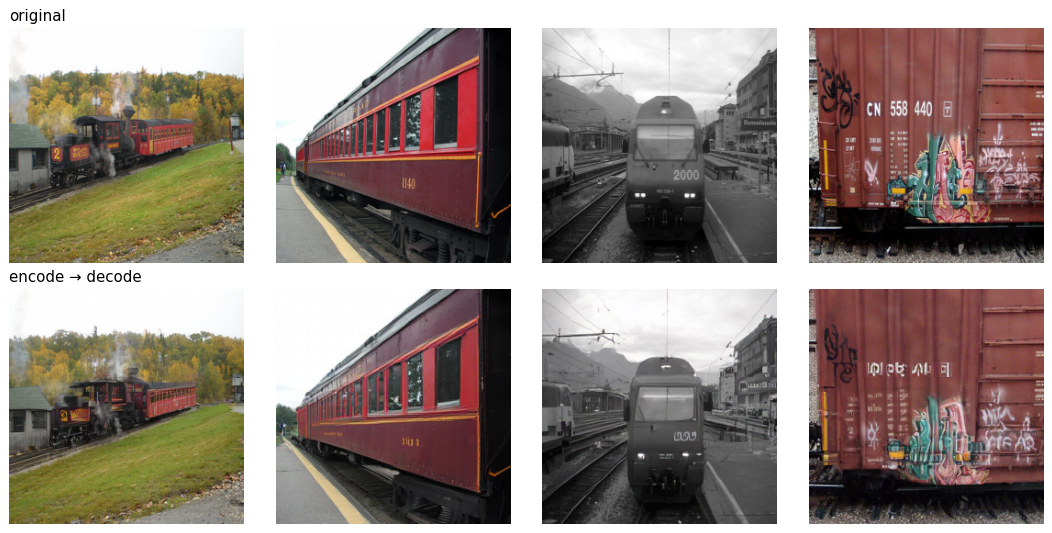

CLIP embedding: (4, 768)


In [12]:
gen_train, _, _ = get_datasets(generator_config.data)
x = torch.stack([gen_train[i][0] for i in range(4)]).to(DEVICE)
with torch.no_grad():
    z, x_T, noise_maps = generator.encode(x, sample_type="ddpm_inv")
    x_rec = generator.decode((z, x_T, noise_maps), sample_type="ddpm_inv")
to_img = lambda t: (t.clamp(-1, 1) * 0.5 + 0.5).permute(1, 2, 0).float().cpu()
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(to_img(x[i])); axes[1, i].imshow(to_img(x_rec[i]))
    axes[0, i].axis("off"); axes[1, i].axis("off")
axes[0, 0].set_title("original", loc="left"); axes[1, 0].set_title("encode → decode", loc="left")
plt.tight_layout(); show(fig)
print("CLIP embedding:", tuple(z.shape))
del generator, dictionary, x, x_rec, z, x_T, noise_maps   # DiDAE loads its own copies
torch.cuda.empty_cache()


## 6. DiDAE: `DiDAEConfig` → `get_adaptor` → `run()`

An *adaptor* in PEAL is a workflow that takes a model (the *student*) and improves it with the help
of a *teacher*. DiDAE's workflow:

1. **distil** the student into a linear probe on the CLIP embedding, so edits can be tested cheaply;
2. **sweep** concept pairs over a pool of training images and count *latent flips*: edits that flip
   the distilled probe;
3. **render** the edits of the best directions with the generator and classify the images with the
   real student: an *ambient flip* flips the student, a *verified flip* also shows the edited concept
   in the rendered image;
4. **rank** the directions by verified flips;
5. ask the **teacher** whether each direction is a real class feature or a shortcut, and optionally
   correct the student.

Every setting lives in `DiDAEConfig`. The values below: concept pairs (`concept_replacement=True`:
one concept off, another on; `False` sweeps single concepts, which gives fewer but smaller edits),
edits up to 3x the observed range of a concept, the 10 best directions with at most 30 renders each.

The teacher here is PEAL's web-feedback teacher with an automatic verdict, which just lets the run
finish: we judge the directions ourselves in step 8. (With `teacher="cluster@8000"` PEAL would serve
a labelling page and wait for you there.)


In [13]:
from peal.adaptors.didae import DiDAEConfig
from peal.adaptors.adaptor_factory import get_adaptor
from peal.explainers.counterfactual_explainer import DAEdistillConfig

explainer_config = load_yaml_config(str(CONFIGS / "didae_experiments/explainers/dae_distill.yaml"), DAEdistillConfig)
explainer_config.sampler = dict(generator_config.sampler)   # the sweep renders with these steps

didae_config = DiDAEConfig(
    data=train_config, test_data=test_config,
    task=TaskConfig(criterions={"ce": 1.0, "l2": 100.0}, output_type="singleclass", output_channels=2, y_selection=["Class"]),
    student=str(student_path),
    generator=generator_config,
    sparse_dictionary=dictionary_config,
    explainer=explainer_config,
    training=load_yaml_config(str(CONFIGS / "cfkd_experiments/training/img_finetuning.yaml"), TrainingConfig),
    teacher={"type": "web", "dir": str(WORK / "didae" / "feedback"), "auto_verdict": "true"},
    base_dir=str(WORK / "didae"),
    # what is swept and how far
    concept_replacement=True, concept_replacement_unique=True, concept_replacement_candidates=64,
    component_bounds_scale=3.0,
    min_train_samples=len(train_set), max_validation_samples=len(val_set),   # the pool of images to edit
    # how much is rendered
    service_mode=True, max_decode_directions=10, max_decode_per_direction=15 if SMALL_GPU else 30,
    decode_selection="deepest", decode_batch_size=4 if SMALL_GPU else 16, top_k_directions=10, max_cf_per_direction=5, max_export_per_direction=None,
    # we correct the model ourselves in step 9
    finetune_iterations=0, run_cfkd_on_false_directions=False,
    overwrite=True, seed=0,
)
run_dir = Path(didae_config.base_dir)
if REUSE and (run_dir / "sweep_results.pt").exists():
    print("reusing", run_dir)
else:
    t0 = time.time(); torch.cuda.reset_peak_memory_stats()
    didae = get_adaptor(didae_config)
    didae.run()
    print(f"DiDAE finished in {(time.time() - t0) / 60:.1f} min, "
          f"peak GPU memory {torch.cuda.max_memory_allocated() / 2**30:.1f} GB")
    del didae; torch.cuda.empty_cache()


Loading pretrained decoder from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/decoder.pt


Loaded normalization stats from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/stats.pt
RAE: encoder=clipproj-vit-L, resolution=256, patch_size=14, hidden_size=1024, decoder_aux_mode=discard, num_aux_tokens=0


[RAEDiffusionAutoencoder] stage 2 loaded from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/stage2_ema.pt (ema); epoch=None step=None


[MSAE] Loaded MSAE with 6144 directions mapped to concepts.


Loading facebook/dinov2-small on cuda...


...

  True directions  (6): [0, 1, 3, 6, 7, 2]


  False directions (0): []


[DiDAE] No false directions — classifier appears unbiased for these directions.


[DiDAE] Workflow complete!


DiDAE finished in 6.9 min, peak GPU memory 19.6 GB


The same run from the command line: DiDAE wrote the resolved config to `run_dir / "config.yaml"`,
so `peal-didae --config <that file>` (a console script of the pip package) repeats it.

## 7. What did DiDAE find?

`sweep_results.pt` holds the ranked directions with their three counts (the funnel latent → ambient →
verified flips). `successful_flips/` holds every verified factual / counterfactual pair, indexed by
`successful_flips/index.json`.


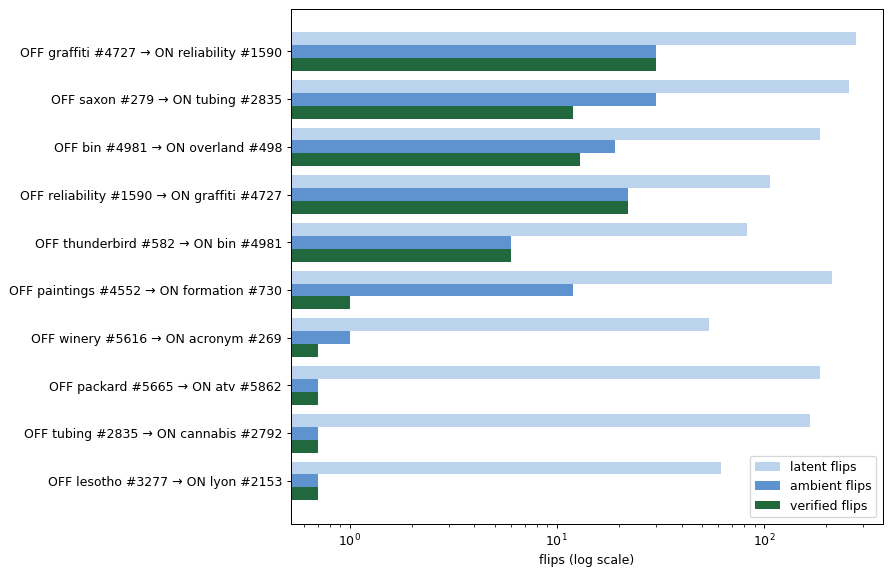

In [14]:
results = torch.load(run_dir / "sweep_results.pt", weights_only=False)
index = {e["direction_idx"]: e for e in json.load(open(run_dir / "successful_flips" / "index.json"))}
short = lambda n: re.sub(r"\s*\(SAE #(\d+)\)", r" #\1", str(n)).replace("  ->  ", " → ")

rows = results[:10][::-1]
y_pos = np.arange(len(rows)); h = 0.27
fig, ax = plt.subplots(figsize=(10, 0.55 * len(rows) + 1))
for label, key, color, off in (("latent flips", "latent_flip_count", "#bcd3ee", h),
                               ("ambient flips", "ambient_flip_count", "#5f93cf", 0),
                               ("verified flips", "success_count", "#22683f", -h)):
    ax.barh(y_pos + off, [max(r[key] or 0, 0.7) for r in rows], height=h, color=color, label=label)
ax.set_yticks(y_pos); ax.set_yticklabels([short(r["dimension_name"]) for r in rows])
ax.set_xscale("log"); ax.set_xlabel("flips (log scale)"); ax.legend(loc="lower right")
plt.tight_layout(); show(fig)


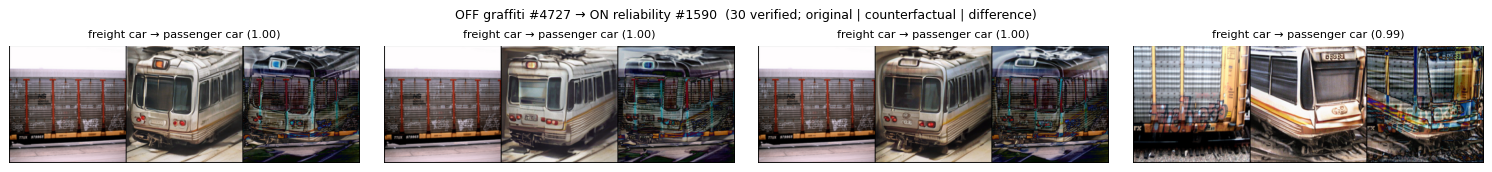

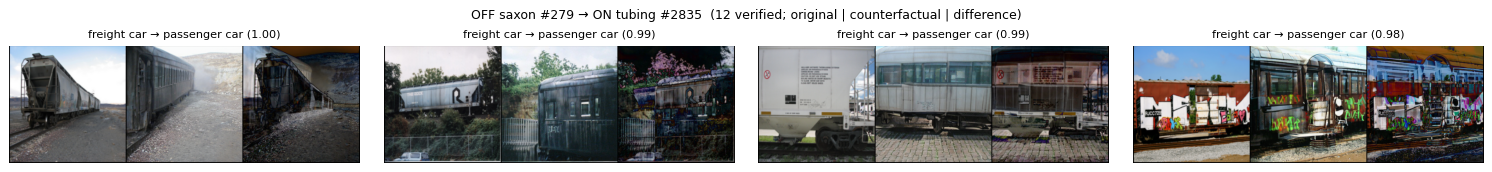

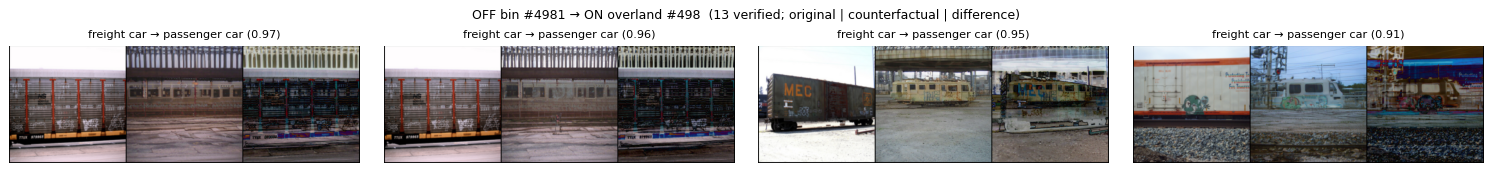

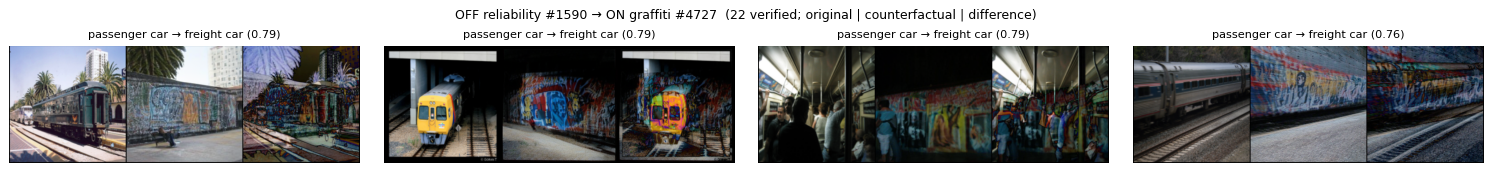

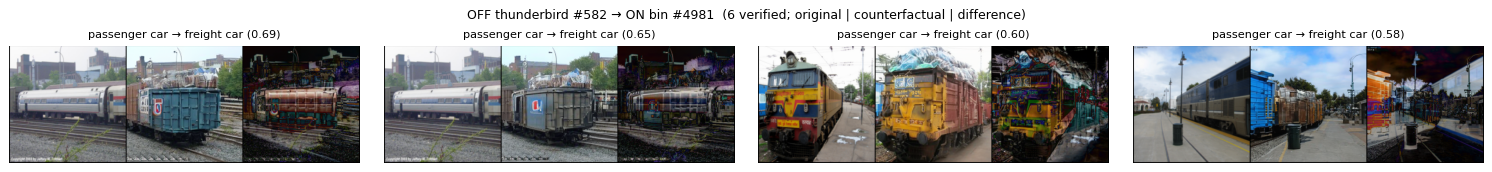

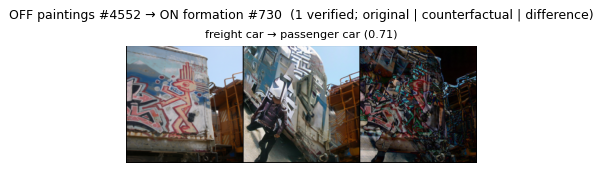

In [15]:
from PIL import Image

def show_pairs(direction_idx, n=4):
    e = index[direction_idx]
    pairs = e["pairs"][:n]
    fig, axes = plt.subplots(1, len(pairs), figsize=(4.2 * len(pairs), 1.9))
    for ax, p in zip(np.atleast_1d(axes), pairs):
        ax.imshow(Image.open(run_dir / "successful_flips" / e["folder"] / p["file"]))
        ax.set_title(f"{CLASS_NAMES[p['orig_class']]} → {CLASS_NAMES[p['target_class']]} "
                     f"({p['confidence']:.2f})", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{short(e['name'])}  ({e['n_verified']} verified; original | counterfactual | difference)", fontsize=10)
    plt.tight_layout(); show(fig)

for r in results[:6]:
    if r["direction_idx"] in index:
        show_pairs(r["direction_idx"])


## 8. Your verdicts

For each direction decide: did the edit change what makes a freight car a freight car (**true**, a
real class feature: the car's shape, doors, windows) or something the classifier should not rely on
(**false**, a shortcut: graffiti, the scenery)?

Look at the pairs above (`show_pairs(direction_idx)` shows any direction) and write your verdicts
into the dict below. As a default the cell marks every direction that edits a concept whose name
contains one of `SHORTCUT_WORDS` as a shortcut and every other direction as a real feature. Edit the
words, or set `verdicts` by hand.


In [16]:
SHORTCUT_WORDS = ["graffiti", "graff", "spray", "mural", "vandal", "paint"]

verdicts = {}
for d_idx, e in index.items():
    names = [vocabulary[int(a)] for a in re.findall(r"SAE #(\d+)", e["name"])]   # the concepts it edits
    verdicts[d_idx] = "false" if any(w in n.lower() for n in names for w in SHORTCUT_WORDS) else "true"
# verdicts = {12: "false", 40: "true"}   # or judge by hand: direction_idx -> "true" | "false"
pd.DataFrame([(short(index[d]["name"]), index[d]["n_verified"], v) for d, v in verdicts.items()],
             columns=["direction", "verified pairs", "verdict"])


,direction,verified pairs,verdict
0,OFF graffiti #4727 → ON reliability #1590,30,false
1,OFF saxon #279 → ON tubing #2835,12,true
2,OFF paintings #4552 → ON formation #730,1,false
3,OFF bin #4981 → ON overland #498,13,true
4,OFF reliability #1590 → ON graffiti #4727,22,false
5,OFF thunderbird #582 → ON bin #4981,6,true


## 9. Correct the classifier: refit only the last layer (DFR)

*Deep feature reweighting* (Kirichenko et al., 2023) keeps the network frozen and retrains only its
final linear layer, an L2 logistic regression on penultimate features. We fit it on

* the training and validation images with their labels (still the shortcut split), and
* half of the verified counterfactuals: those of a **false** (shortcut) direction keep their
  *original* class (spraying graffiti on a passenger car does not make it a freight car), those of a
  **true** direction get the *target* class.

Two numbers show whether it worked: how many **held-out shortcut counterfactuals** - the other half -
still fool the model, and the accuracy on the **clean freight cars** of the held-out set (real images
the shortcut got wrong).


In [17]:
from sklearn.linear_model import LogisticRegression

F_train, y_train = predict_features(student, train_set)
F_val, y_val = predict_features(student, val_set)

cf_images, cf_labels, cf_kind, cf_sample = [], [], [], []
for d_idx, verdict in verdicts.items():
    e = index[d_idx]
    for p in e["pairs"]:
        img = Image.open(run_dir / "successful_flips" / e["folder"] / p["file"].replace("_pair", "_cf", 1)).convert("RGB")
        img = img.resize(tuple(train_config.input_size[1:][::-1]))
        cf_images.append(torch.from_numpy(np.asarray(img, dtype=np.float32) / 255).permute(2, 0, 1))
        cf_labels.append(p["orig_class"] if verdict == "false" else p["target_class"])
        cf_kind.append(verdict); cf_sample.append(p["sample_idx"])
F_cf, _ = predict_features(student, torch.stack(cf_images))
y_cf, cf_kind, cf_sample = np.array(cf_labels), np.array(cf_kind), np.array(cf_sample)
cf_held_out = np.isin(cf_sample, np.unique(cf_sample)[1::2])   # every other source image: none on both sides
print(f"{len(y_cf)} counterfactuals ({int((cf_kind == 'false').sum())} from shortcut directions), "
      f"{int(cf_held_out.sum())} held out")

X = np.concatenate([F_train, F_val, F_cf[~cf_held_out]])
y = np.concatenate([y_train, y_val, y_cf[~cf_held_out]])
is_cf = np.r_[np.zeros(len(y_train) + len(y_val), bool), np.ones(int((~cf_held_out).sum()), bool)]
mu, sd = X[~is_cf].mean(0), X[~is_cf].std(0) + 1e-6
weight = np.where(is_cf, (~is_cf).sum() / max(is_cf.sum(), 1), 1.0)   # counterfactuals: half the weight
clf = LogisticRegression(C=0.1, class_weight="balanced", max_iter=3000).fit((X - mu) / sd, y, sample_weight=weight)
coef = clf.coef_[0] / sd
intercept = clf.intercept_[0] - (clf.coef_[0] * mu / sd).sum()
new_last = torch.nn.Linear(coef.shape[0], 2, bias=True)   # two logits whose softmax is the fitted sigmoid
new_last.weight.data = torch.tensor(np.stack([-coef / 2, coef / 2]), dtype=torch.float32)
new_last.bias.data = torch.tensor([-intercept / 2, intercept / 2], dtype=torch.float32)

def fooled(Wh, bh):
    mask = cf_held_out & (cf_kind == "false")
    return round(float(((F_cf[mask] @ Wh.T + bh).argmax(1) != y_cf[mask]).mean()), 3) if mask.any() else None

W_new, b_new = new_last.weight.data.numpy(), new_last.bias.data.numpy()
after = group_report((F_test @ W_new.T + b_new).argmax(1))
pd.DataFrame({"before": {**before, "held-out shortcut counterfactuals that fool it": fooled(W, b)},
              "after DFR": {**after, "held-out shortcut counterfactuals that fool it": fooled(W_new, b_new)}}).T


84 counterfactuals (53 from shortcut directions), 42 held out


,"freight car, graffiti","freight car, clean","passenger car, clean",overall,worst group,held-out shortcut counterfactuals that fool it
before,0.99,0.694,1.0,0.933,0.694,1.000
after DFR,0.99,0.629,1.0,0.920,0.629,0.036


**Reading the result.** The held-out shortcut counterfactuals are the direct test: before the
correction they all fool the model, afterwards (almost) none do - the refit removed the shortcut that
the counterfactuals demonstrate. The clean freight cars are the harder test: real photos the shortcut
gets wrong. A last-layer refit on a few dozen *rendered* counterfactuals does not reliably carry over to
them. In four runs of this notebook their accuracy changed by -8, -6.5, -3 and +3 points (62 images:
one image is 1.6 points). Finding the shortcut is the reliable part here; repairing a model for real
photos needs more than this demo's handful of rendered images.

Write the new head into the model and save it like any PEAL predictor; `export_to_onnx` writes an
ONNX copy (for the web demo, for instance).


In [18]:
from peal.architectures.onnx_predictor import export_to_onnx

student.fc = new_last.to(DEVICE)          # TorchvisionModel keeps its head in .fc (see get_last_layer())
corrected = WORK / "dinov3_linear_probe_dfr"
corrected.mkdir(parents=True, exist_ok=True)
torch.save(student, corrected / "model.cpl")
print("saved", corrected / "model.cpl")
EXPORT_ONNX = False
if EXPORT_ONNX:
    export_to_onnx(student.cpu(), str(corrected / "model.onnx"), input_shape=train_config.input_size)


saved /home/space/datasets/peal/peal_runs/notebook_sim/runs_final4/trains_tour/dinov3_linear_probe_dfr/model.cpl


## Where next

* **Other explainers, same building blocks:** notebook 01 explains and corrects a classifier with CFKD
  and SCE counterfactuals from a pretrained ImageNet diffusion model.
* **Your own model and data:** notebook 02 shows the contract for an ONNX model and a folder of
  images; notebook 03 runs DiDAE on exactly that.
* **The same without code:** the web demo (`peal/web`, see `deploy/spark/README.md`) takes an ONNX
  model and a zip of images and runs steps 6-9 with a feedback page.
* **A full correction:** CFKD fine-tunes the whole network on counterfactuals and a teacher's verdicts
  (notebook 01, step 6) instead of refitting one layer.
* **The same from the command line:** `peal-didae --config <run_dir>/config.yaml`.
